In [10]:
!pip install matplotlib seaborn scipy

Defaulting to user installation because normal site-packages is not writeable


In [11]:
# 1. Setup
import os
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

DATA_PROCESSED_PATH = "./data/processed/"
sns.set(style="whitegrid")

In [12]:
# 2. Load data
transactions = pd.read_csv(os.path.join(DATA_PROCESSED_PATH, "SAML-D_clean.csv"))
transactions.head()


,Time,Date,Sender_account,Receiver_account,Amount,Payment_currency,Received_currency,Sender_bank_location,Receiver_bank_location,Payment_type,Is_laundering,Laundering_type,Datetime
0,10:35:19,2022-10-07,8724731955,2769355426,1459.15,UK pounds,UK pounds,UK,UK,Cash Deposit,0,Normal_Cash_Deposits,2022-10-07 10:35:19
1,10:35:31,2022-10-07,5119661534,9734073275,2342.31,UK pounds,UK pounds,UK,UK,Debit card,0,Normal_Small_Fan_Out,2022-10-07 10:35:31
2,10:35:46,2022-10-07,3709430533,9172843471,5274.76,UK pounds,UK pounds,UK,UK,Debit card,0,Normal_Fan_Out,2022-10-07 10:35:46
3,10:36:05,2022-10-07,1203252958,8500212178,2438.30,UK pounds,Mexican Peso,UK,Mexico,Cross-border,0,Normal_Group,2022-10-07 10:36:05
4,10:36:34,2022-10-07,7669236826,6044424887,8560.28,UK pounds,UK pounds,UK,UK,ACH,0,Normal_Fan_Out,2022-10-07 10:36:34


In [13]:
# 3. Compare amount distributions: suspicious vs non-suspicious
suspicious_amounts = transactions.loc[transactions["Is_laundering"] == 1, "Amount"]
normal_amounts = transactions.loc[transactions["Is_laundering"] == 0, "Amount"]

print("Suspicious mean:", suspicious_amounts.mean())
print("Normal mean:", normal_amounts.mean())


Suspicious mean: 46622.37315395273
Normal mean: 8735.978207672664


In [14]:
# 4. Statistical test (e.g. Mann-Whitney U if non-normal)
u_stat, p_value = stats.mannwhitneyu(suspicious_amounts, normal_amounts, alternative="two-sided")
print("Mann-Whitney U:", u_stat, "p-value:", p_value)


Mann-Whitney U: 459587288.0 p-value: 0.01947220674066716


In [15]:
# 5. Region / corridor vs suspicion (chi-square test)
# Example using sender_region and is_suspicious
contingency = pd.crosstab(transactions["Sender_bank_location"], transactions["Is_laundering"])
chi2, p, dof, expected = stats.chi2_contingency(contingency)
print("Chi-square:", chi2, "p-value:", p)


Chi-square: 58.26774093236789 p-value: 2.023866458201594e-06


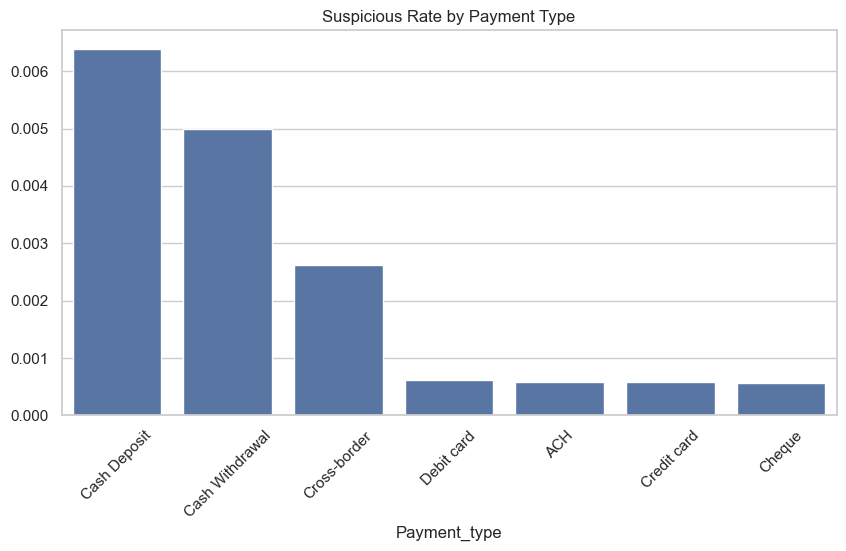

In [16]:
# 6. Visualise key statistically significant differences
plt.figure(figsize=(10, 5))
suspicious_rate_by_type = (
    transactions.groupby("Payment_type")["Is_laundering"]
    .mean()
    .sort_values(ascending=False)
)
sns.barplot(x=suspicious_rate_by_type.index, y=suspicious_rate_by_type.values)
plt.xticks(rotation=45)
plt.title("Suspicious Rate by Payment Type")
plt.show()
